## Install XGBoost and Import Libraries

In [1]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   - -------------------------------------- 3.9/101.7 MB 17.4 MB/s eta 0:00:06
   -- ------------------------------------- 7.1/101.7 MB 16.8 MB/s eta 0:00:06
   --- ------------------------------------ 10.0/101.7 MB 15.7 MB/s eta 0:00:06
   ---- ----------------------------------- 12.6/101.7 MB 14.8 MB/s eta 0:00:07
   ------ --------------------------------- 15.7/101.7 MB 14.9 MB/s eta 0:00:06
   ------- -------------------------------- 19.1/101.7 MB 15.0 MB/s eta 0:00:06
   -------- ------------------------------- 20.7/101.7 MB 14.1 MB/s eta 0:00:06
   --------- ------------------------------ 23.3/101.7 MB 13.7 MB/s eta 0:00:06
   --------- ------------------------------ 25.2/101.7 MB 13.0 MB/s eta 0:00:06
   ---------- ----------------------------- 25.4/101.7 MB 13.0 MB/s eta 0:00:06
   ---------- ----------------------------- 25.4/101.7 MB 13

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

## Load and Veiw data

In [4]:
# Load the dataset
df = pd.read_csv('flu-ili-byregion-fluseason (2).csv')

In [5]:
# Display the first few rows of the dataset
df.head()

,season,date_code,weekending,region,Total_ILI,Total_Patients_Seen,Percent_ILI,Number_Providers_Reporting
0,2001-2002,200140,10/6/2001,Bay Area,3,135,2.22,2
1,2001-2002,200140,10/6/2001,California,25,1211,2.06,14
2,2001-2002,200140,10/6/2001,Central,0,0,NaN,0
3,2001-2002,200140,10/6/2001,Lower Southern,2,336,0.60,4
4,2001-2002,200140,10/6/2001,Northern,20,529,3.78,4


In [6]:
df.shape

(5946, 8)

In [7]:
df.isnull().sum()

season                         0
date_code                      0
weekending                     0
region                         0
Total_ILI                      0
Total_Patients_Seen            0
Percent_ILI                   29
Number_Providers_Reporting     0
dtype: int64

## Pre-Processing Steps

In [8]:
# 1. Fill missing values in 'Percent_ILI' with 0, assuming that missing values indicate no cases of influenza-like illness reported
df['Percent_ILI'] = df['Percent_ILI'].fillna(0)
df

,season,date_code,weekending,region,Total_ILI,Total_Patients_Seen,Percent_ILI,Number_Providers_Reporting
0,2001-2002,200140,10/6/2001,Bay Area,3,135,2.22,2
1,2001-2002,200140,10/6/2001,California,25,1211,2.06,14
2,2001-2002,200140,10/6/2001,Central,0,0,0.00,0
3,2001-2002,200140,10/6/2001,Lower Southern,2,336,0.60,4
4,2001-2002,200140,10/6/2001,Northern,20,529,3.78,4
...,...,...,...,...,...,...,...,...
5941,2019-2020,202039,9/26/2020,California,448,50902,0.88,87
5942,2019-2020,202039,9/26/2020,Central,0,447,0.00,3
5943,2019-2020,202039,9/26/2020,Lower Southern,134,21280,0.63,36
5944,2019-2020,202039,9/26/2020,Northern,122,14125,0.86,17


In [9]:
df.isnull().sum()

season                        0
date_code                     0
weekending                    0
region                        0
Total_ILI                     0
Total_Patients_Seen           0
Percent_ILI                   0
Number_Providers_Reporting    0
dtype: int64

In [10]:
# 2. Convert strings to datetime objects to enable time-based operations
df['weekending'] = pd.to_datetime(df['weekending'])

# Extract time components for further analysis or filtering
df['year'] = df['weekending'].dt.year
df['month'] = df['weekending'].dt.month

# Extract the ISO week number as an integer to get a consistent week identifier across years
# .isocalendar().week returns the week number (1-53), and we convert it to an integer type for easier handling in analysis 
df['week'] = df['weekending'].dt.isocalendar().week.astype(int)

In [11]:
df

,season,date_code,weekending,region,Total_ILI,Total_Patients_Seen,Percent_ILI,Number_Providers_Reporting,year,month,week
0,2001-2002,200140,2001-10-06,Bay Area,3,135,2.22,2,2001,10,40
1,2001-2002,200140,2001-10-06,California,25,1211,2.06,14,2001,10,40
2,2001-2002,200140,2001-10-06,Central,0,0,0.00,0,2001,10,40
3,2001-2002,200140,2001-10-06,Lower Southern,2,336,0.60,4,2001,10,40
4,2001-2002,200140,2001-10-06,Northern,20,529,3.78,4,2001,10,40
...,...,...,...,...,...,...,...,...,...,...,...
5941,2019-2020,202039,2020-09-26,California,448,50902,0.88,87,2020,9,39
5942,2019-2020,202039,2020-09-26,Central,0,447,0.00,3,2020,9,39
5943,2019-2020,202039,2020-09-26,Lower Southern,134,21280,0.63,36,2020,9,39
5944,2019-2020,202039,2020-09-26,Northern,122,14125,0.86,17,2020,9,39


In [12]:
# Analyze the distribution of the 'region' column to understand how many records belong to each region
df['region'].value_counts()

region
Bay Area          991
California        991
Central           991
Lower Southern    991
Northern          991
Upper Southern    991
Name: count, dtype: int64

## Exploratory Data Analysis

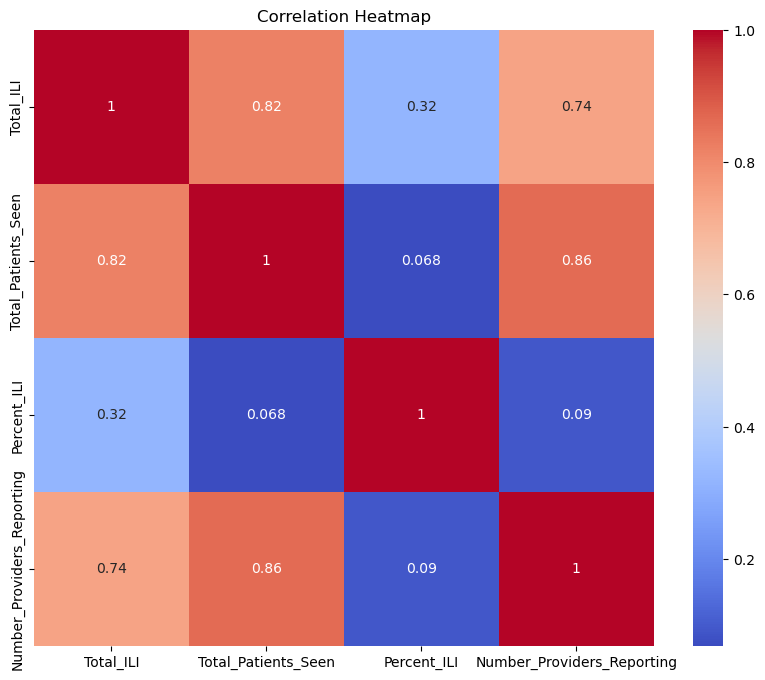

In [13]:
# 3. After preprocessing, we can now analyze the correlations between key features and Percent_ILI. We will select relevant features and compute the correlation matrix, then visualize it using a heatmap.
features = ['Total_ILI','Total_Patients_Seen', 'Percent_ILI','Number_Providers_Reporting']
corr = df[features].corr()

# Create a heatmap to visualize correlations 
# Annotations (annot=True) show the correlation coefficient values
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

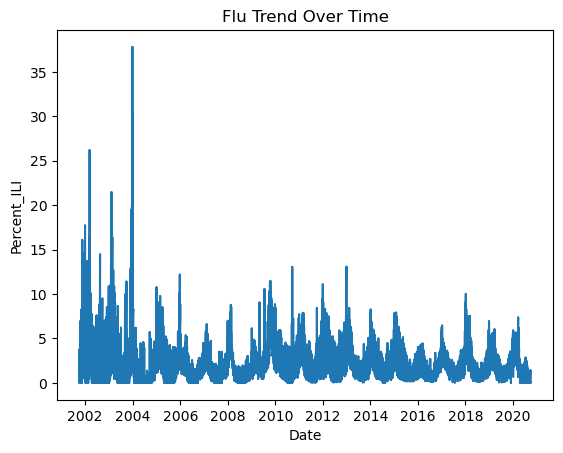

In [14]:
# We can visualize the trend of Percent_ILI over time to see how influenza-like illness has evolved across the weeks and years in the dataset.
plt.figure()
plt.plot(df['weekending'], df['Percent_ILI'])
plt.title("Flu Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Percent_ILI")
plt.show()

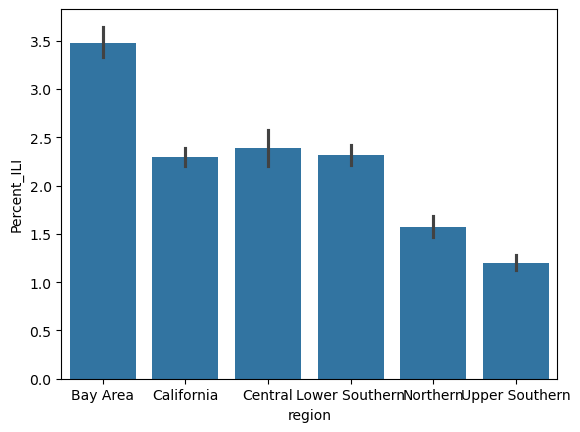

In [15]:
# We can also analyze the distribution of Percent_ILI across different regions to see if there are regional differences in influenza-like illness rates.
sns.barplot(data=df, x='region', y='Percent_ILI')
plt.show()

## Modeling

In [16]:
# 4. Define features (X) and target (y)
features = ['Total_ILI', 'Total_Patients_Seen', 
                 'Number_Providers_Reporting', 'region', 'year']

X = df[features]
y = df['Percent_ILI']

In [17]:
# For linear regression, we need to encode the categorical 'region' variable using one-hot encoding. This will create new binary columns for each region, allowing the linear regression model to interpret the categorical data.
# drop_first=True reduces multi-collinearity (avoids dummy variable trap)
X_lr = pd.get_dummies(X, columns=['region'], drop_first=True)

In [18]:
# For tree-based models, we can use one-hot encoding without dropping the first category, as tree-based models are not affected by multicollinearity in the same way linear regression is. 
# This allows us to retain all region categories for better model performance.

X_tree = pd.get_dummies(X, columns=['region'], drop_first=False)

## Train- Test Split

In [19]:
# 5. Train - test split
# Linear Regression split
# Split data into training (80%) and testing (20%) sets
# random_state=42 ensures reproducibility of the split by providing a fixed set for the random number generator. 
X_train_lr, X_test_lr, y_train, y_test = train_test_split(
    X_lr, y, test_size=0.2, random_state=42
)

# Tree models split
# Split data into training (80%) and testing (20%) sets
# random_state=42 ensures reproducibility of the split by providing a fixed set for the random number generator. 
X_train_tree, X_test_tree, _, _ = train_test_split(
    X_tree, y, test_size=0.2, random_state=42
)


## Scaling

In [20]:
# 6. Scaling the features
# For linear regression, we need to standardize the features to ensure that they are on the same scale. This is important because linear regression is sensitive to the scale of the features, and standardizing can improve model performance and convergence.
# Initialize the scaler object
scaler = StandardScaler()

# Fit to training data to learn mean/std, then transform it to standardize the training features.
X_train_lr_scaled = scaler.fit_transform(X_train_lr)

# Transform test data using the parameters learned ONLY from X_train to prevent data leakage. 
# This ensures that the test set is scaled in the same way as the training set without using any information from the test set during fitting.
X_test_lr_scaled = scaler.transform(X_test_lr)

## Models

### linear regression

In [21]:
# 1. Linear Regression
# Initialize the model 
lr_model = LinearRegression()

# Train the model: Fit the estimator to the scaled training data to learn coefficients 
lr_model.fit(X_train_lr_scaled, y_train)

# Make predictions: Use the trained model to predict target values for the test set 
y_pred_lr = lr_model.predict(X_test_lr_scaled)

# Evaluate performance: Print key metrics to assess model accuracy
print("Linear Regression:")

# Mean Squared Error (MSE): Measures the average squared difference between actual and predicted values
# A value closer to 0 indicates better performance 
print("MSE:", mean_squared_error(y_test, y_pred_lr))

# R-squared (R2): Represents the proportion of variance explained by the model
# A score of 1.0 is a perfect fit 
print("R²:", r2_score(y_test, y_pred_lr))

Linear Regression:
MSE: 3.268636231772611
R²: 0.31747491000134054


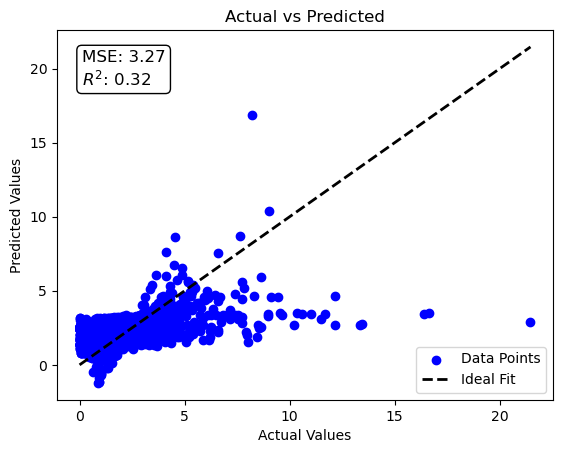

In [28]:
# Create scatter plot
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

plt.scatter(y_test, y_pred_lr, color='blue', label='Data Points')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal Fit')

# Add MSE and R^2 to plot
plt.annotate(f'MSE: {mse:.2f}\n$R^2$: {r2:.2f}', 
             xy=(0.05, 0.85), 
             xycoords='axes fraction',
             fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()

### Random Forest

In [22]:
# 2. Random Forest
# Initialize and train a Random Forest Regressor with 100 trees 
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_tree, y_train)

# Predict target values for the test set
y_pred_rf = rf_model.predict(X_test_tree)

# Evaluate model performance using Mean Squared Error and R-squared metrics
print("Random Forest:")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R²:", r2_score(y_test, y_pred_rf))

Random Forest:
MSE: 0.13322056210924418
R²: 0.9721821672110715


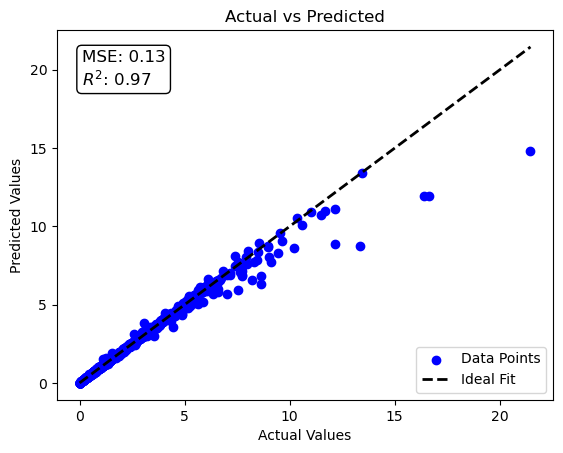

In [29]:
# Create scatter plot
mse = mean_squared_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

plt.scatter(y_test, y_pred_rf, color='blue', label='Data Points')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal Fit')

# Add MSE and R^2 to plot
plt.annotate(f'MSE: {mse:.2f}\n$R^2$: {r2:.2f}', 
             xy=(0.05, 0.85), 
             xycoords='axes fraction',
             fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()

### XGBoost

In [30]:
# 1. Initialize the XGBoost Regressor with specified hyperparameters
# n_estimators: Number of boosting rounds (trees) to build.
# random_state: Ensures reproducibility of results.
# eval_metric: Metric used to evaluate model performance (Root Mean Squared Error).
xgb_model = XGBRegressor(n_estimators=100, random_state=42, eval_metric='rmse')

# 2. Train (fit) the model
# eval_set: Monitors performance on both training and testing sets during training.
xgb_model.fit(X_train_tree, y_train, eval_set=[(X_train_tree, y_train), (X_test_tree, y_test)])

# Make predictions on unseen test data
y_pred_xgb = xgb_model.predict(X_test_tree) 

print('XGBoost:')

# Calculate and print Mean Squared Error (lower is better). 
print('MSE:', mean_squared_error(y_test, y_pred_xgb)) 

# Calculate and print R-squared score (higher is better).
print('R2:', r2_score(y_test, y_pred_xgb))

[0]	validation_0-rmse:1.66637	validation_1-rmse:1.70750
[1]	validation_0-rmse:1.29667	validation_1-rmse:1.36162
[2]	validation_0-rmse:1.02076	validation_1-rmse:1.08543
[3]	validation_0-rmse:0.81778	validation_1-rmse:0.88784
[4]	validation_0-rmse:0.65604	validation_1-rmse:0.74249
[5]	validation_0-rmse:0.53060	validation_1-rmse:0.63105
[6]	validation_0-rmse:0.43749	validation_1-rmse:0.54991
[7]	validation_0-rmse:0.36803	validation_1-rmse:0.48690
[8]	validation_0-rmse:0.31661	validation_1-rmse:0.44168
[9]	validation_0-rmse:0.28301	validation_1-rmse:0.40503
[10]	validation_0-rmse:0.25289	validation_1-rmse:0.37749
[11]	validation_0-rmse:0.22540	validation_1-rmse:0.36001
[12]	validation_0-rmse:0.21004	validation_1-rmse:0.34776
[13]	validation_0-rmse:0.19547	validation_1-rmse:0.32602
[14]	validation_0-rmse:0.19076	validation_1-rmse:0.31997
[15]	validation_0-rmse:0.18173	validation_1-rmse:0.31528
[16]	validation_0-rmse:0.17581	validation_1-rmse:0.31148
[17]	validation_0-rmse:0.17311	validation

In [31]:
# Extract evaluation results to analyze the learning curve of the XGBoost model during training. 
# This will allow us to visualize how the model's performance evolved over the boosting rounds.
results = xgb_model.evals_result()

# Extract the RMSE values for both training and validation sets from the evaluation results.
train_rmse = results['validation_0']['rmse']

# Extract the RMSE values for the validation set to analyze how the model's performance on unseen data evolved during training.
test_rmse = results['validation_1']['rmse']

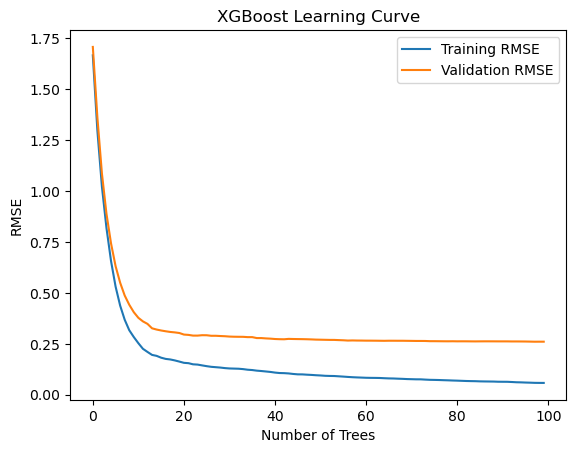

In [32]:
plt.figure()

# Plot training error (RMSE) against the number of boosting iterations (trees) 
plt.plot(train_rmse, label='Training RMSE')

# Plot validation error (RMSE) to monitor for overfitting
plt.plot(test_rmse, label='Validation RMSE')

plt.xlabel('Number of Trees') # The x-axis represents the number of boosting rounds
plt.ylabel('RMSE') # The y-axis represents the Root Mean Square Error
plt.title('XGBoost Learning Curve')
plt.legend()
plt.show()

In [23]:
# 3. XGBoost
# Initialize the XGBoost Regressor with specified hyperparameters
# n_estimators: Number of boosting rounds (trees)
# random_state: Ensures reproducibility of results (same sequence of random numbers for consistent results across runs)
xgb_model = XGBRegressor(n_estimators=100, random_state=42)

# Train the model using the training dataset 
xgb_model.fit(X_train_tree, y_train)

# Predict target values for the test set 
y_pred_xgb = xgb_model.predict(X_test_tree)

# Evaluate the model performance 
print("XGBoost:")
print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("R²:", r2_score(y_test, y_pred_xgb))

XGBoost:
MSE: 0.06779920911023807
R²: 0.9858428231168728


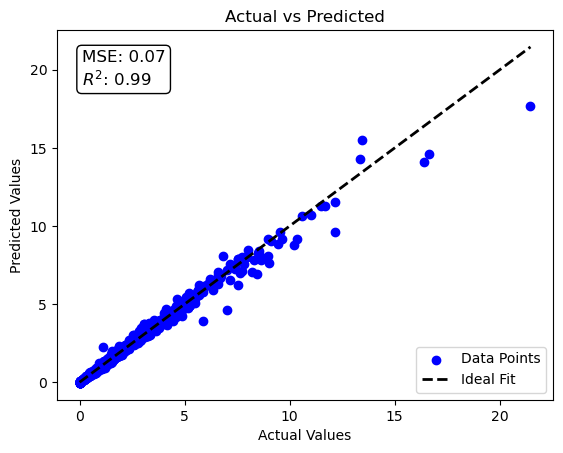

In [33]:
# Create scatter plot
mse = mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

plt.scatter(y_test, y_pred_xgb, color='blue', label='Data Points')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal Fit')

# Add MSE and R^2 to plot
plt.annotate(f'MSE: {mse:.2f}\n$R^2$: {r2:.2f}', 
             xy=(0.05, 0.85), 
             xycoords='axes fraction',
             fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()

## Feature Importance Graphs

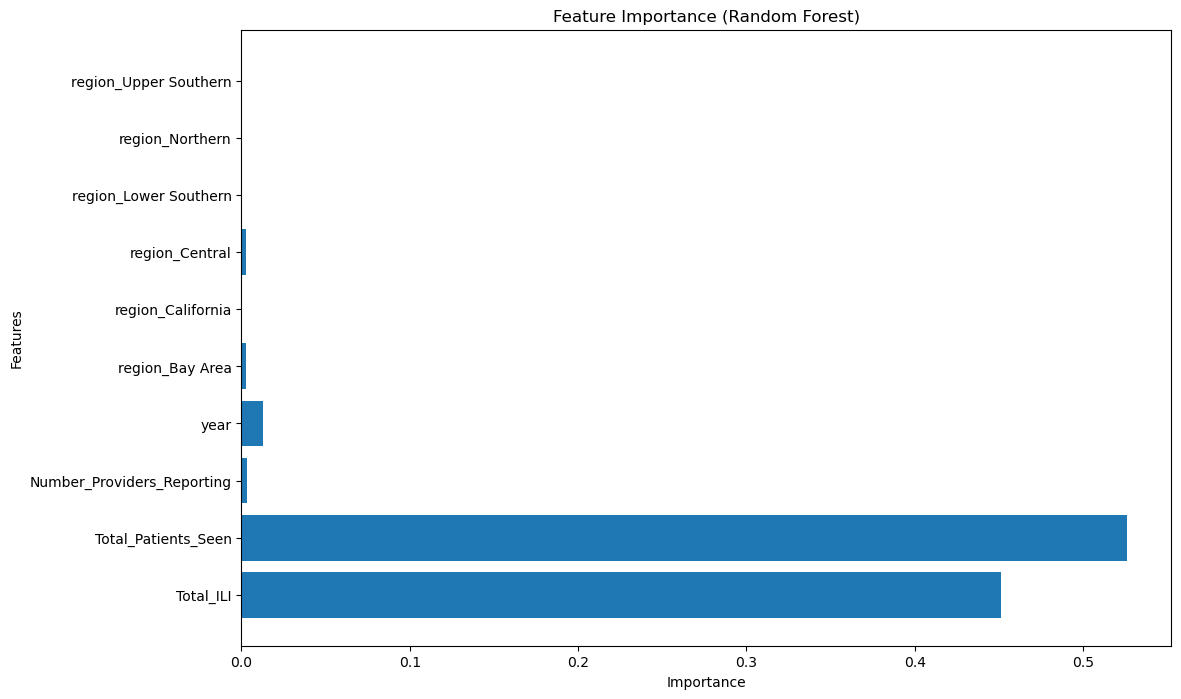

In [24]:
# 1. Feature importance from Random Forest.
# Higher values indicate more important features for predicting percent_ILI 
importances = rf_model.feature_importances_ 

# Plot
plt.figure(figsize=(12, 8))  # bigger figure
plt.barh(X_tree.columns, importances) # Use X_tree.columns to provide the labels for the y-axis. 
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

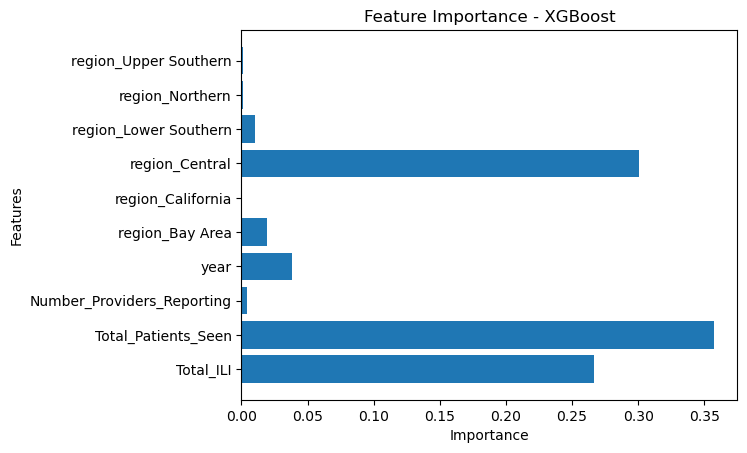

In [25]:
# 2. Feature importance from XGBoost.
# Higher values indicate more important features for predicting percent_ILI 
importances = xgb_model.feature_importances_ 

plt.figure()
plt.barh(X_tree.columns, importances) # Use X_tree.columns to provide the labels for the y-axis. 
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

## Model Comparison Graph

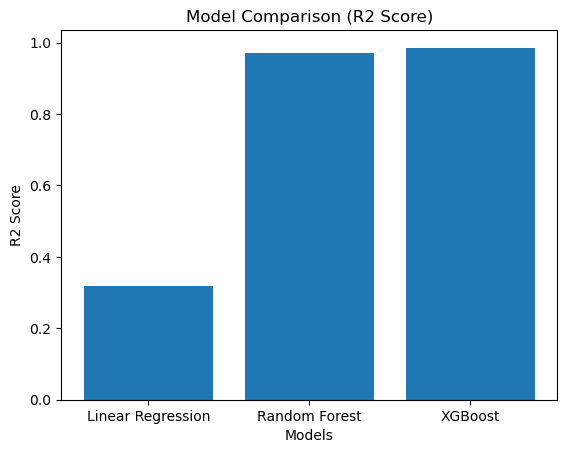

In [26]:
# Define models and their corresponding R2 scores
# We create a list of model names and a list of their corresponding R2 scores to facilitate the comparison of model performance. This allows us to easily visualize which model performs best in terms of explaining the variance in the target variable (Percent_ILI).
models = ['Linear Regression', 'Random Forest', 'XGBoost']
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_xgb)
]

# Create the bar plot to visually compare the accuracy of the three models. Each bar represents a model, and its height corresponds to the accuracy score.
plt.figure()
plt.bar(models, r2_scores)
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()

## K-Fold Cross Validation

In [27]:
# Set up the K-Fold cross-validation strategy.
# - n_splits=5: Data is split into 5 subsets (folds). The model trains on 4 and tests on 1, repeating 5 times.
# - shuffle=True: The data is shuffled before splitting, ensuring no bias from original data ordering.
# - random_state=42: Ensures reproducibility. Using the same integer ensures the same splits every time the code runs.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate Linear Regression (linreg) using the encoded features for linear regression
lr_scores = cross_val_score(lr_model, X_lr, y, cv=kf, scoring='r2')
print("Linear Regression CV R2:", lr_scores.mean())

# Evaluate Random Forest (rf) using the encoded features for tree-based models
rf_scores = cross_val_score(rf_model, X_tree, y, cv=kf, scoring='r2')
print("Random Forest CV R2:", rf_scores.mean())

# Evaluate XGBoost (xgb) using the encoded features for tree-based models
xgb_scores = cross_val_score(xgb_model, X_tree, y, cv=kf, scoring='r2')
print("XGBoost CV R2:", xgb_scores.mean())

Linear Regression CV R2: 0.28748657298561325
Random Forest CV R2: 0.9567861475274771
XGBoost CV R2: 0.9567797174403031
